# Modèle de régression linéaire

### Objectif: estimer au mieux la température de la surface terrestre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

In [2]:
import sklearn
print(sklearn.__version__)

1.9.0


In [3]:
# Import dataset
df = pd.read_csv('Dataset_LST_Massive_20k.csv')
df.head()

,Region_Type,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
0,Dense_Urban_Temperate,48.8722,2.2984,68,0,0.0384,0.0970,20.78,50,200,10.23
1,Dense_Urban_Temperate,48.8802,2.3543,62,0,0.0196,0.0926,41.81,50,200,9.30
2,Dense_Urban_Temperate,48.8444,2.3000,43,0,0.0535,0.1158,20.33,50,200,10.36
3,Dense_Urban_Temperate,48.8535,2.3226,40,0,0.0757,0.1049,34.26,50,200,9.87
4,Dense_Urban_Temperate,48.8202,2.3462,64,0,0.1615,0.0870,39.36,50,200,8.06


In [4]:
df.shape

(16779, 11)

In [5]:
# éléments vides, max, min (describe)
df.describe()

,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
count,16779.000000,16779.000000,16779.000000,16779.000000,16779.000000,16779.000000,16779.00000,16779.0,16779.0,16779.000000
mean,21.559065,18.845094,706.484832,166.715895,0.315781,0.186802,28.52455,50.0,200.0,17.153472
std,35.273400,81.684270,1269.178550,105.160231,0.296922,0.244142,15.21091,0.0,0.0,23.497670
min,-77.336800,-99.841700,0.000000,0.000000,-0.182900,0.008700,2.00000,50.0,200.0,-58.430000
25%,-2.362500,-62.829900,33.000000,60.000000,0.072500,0.046600,15.41500,50.0,200.0,9.325000
50%,27.800900,11.641300,167.000000,152.000000,0.224800,0.091000,28.60000,50.0,200.0,25.910000
75%,48.853500,98.017800,602.000000,273.000000,0.560100,0.200000,41.66000,50.0,200.0,30.960000
max,73.472600,167.018400,6491.000000,335.000000,0.940000,0.996000,55.00000,50.0,200.0,57.460000


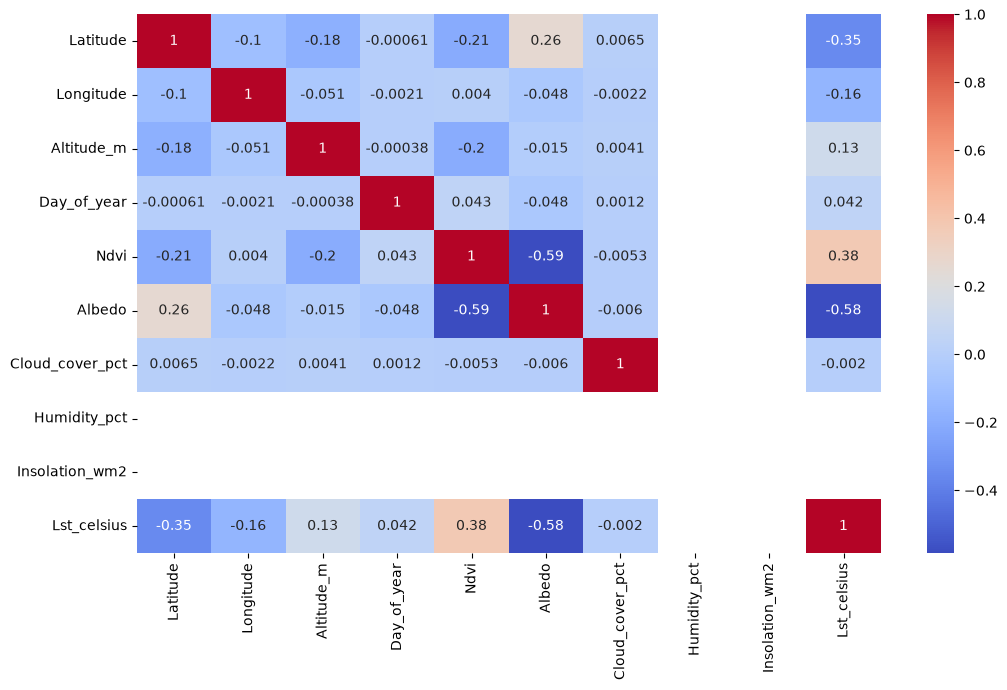

In [6]:
# corrélation
plt.figure(figsize=(12, 7)) # Crée la figure avec la taille désirée
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show() # Affiche le graphique

In [7]:
df.duplicated().value_counts()

False    16779
Name: count, dtype: int64

In [8]:
df.isna().sum()

Region_Type        0
Latitude           0
Longitude          0
Altitude_m         0
Day_of_year        0
Ndvi               0
Albedo             0
Cloud_cover_pct    0
Humidity_pct       0
Insolation_wm2     0
Lst_celsius        0
dtype: int64

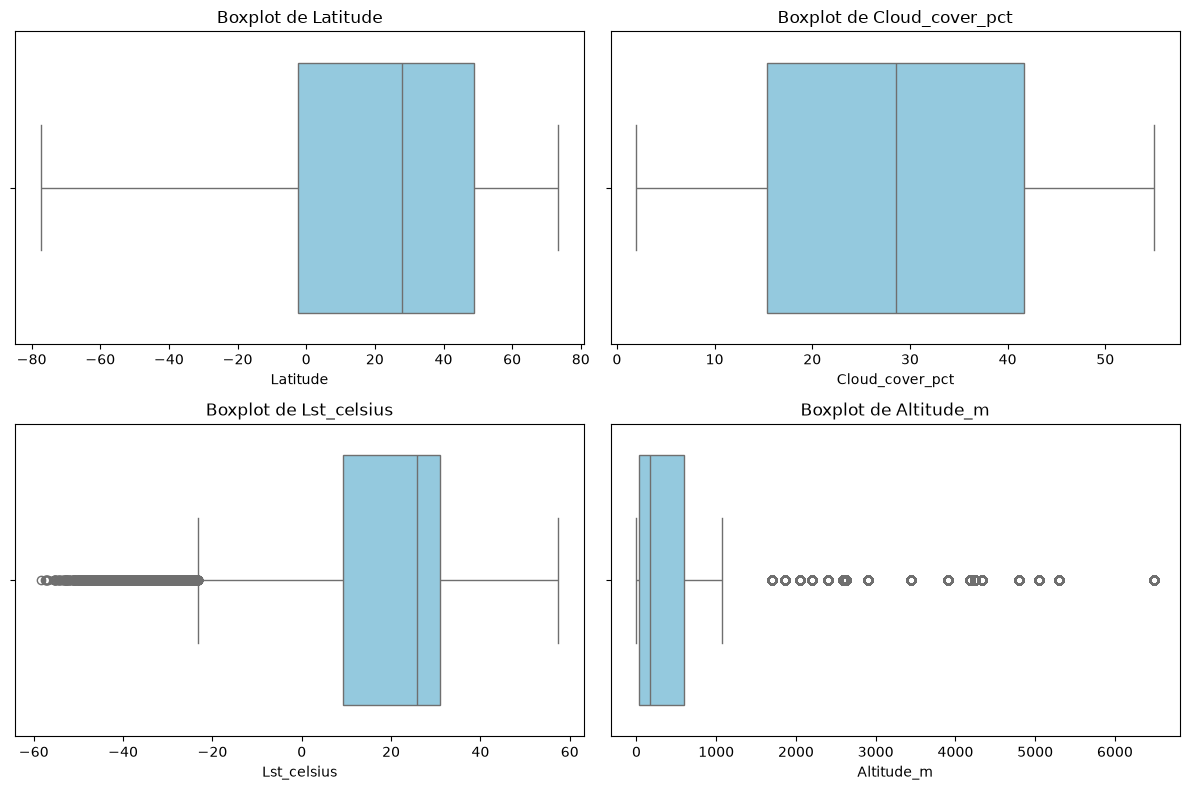

In [9]:
cols = ['Latitude', 'Cloud_cover_pct', 'Lst_celsius', 'Altitude_m']

plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df[col].dropna(), orient='h', color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [10]:
df.columns
df.dtypes

Region_Type            str
Latitude           float64
Longitude          float64
Altitude_m           int64
Day_of_year          int64
Ndvi               float64
Albedo             float64
Cloud_cover_pct    float64
Humidity_pct         int64
Insolation_wm2       int64
Lst_celsius        float64
dtype: object

In [11]:
# Décomposition de la variable temporelle

df["day_sin"] = np.sin(
    2*np.pi*df["Day_of_year"]/365
)

df["day_cos"] = np.cos(
    2*np.pi*df["Day_of_year"]/365
)

df.drop(
    columns=["Day_of_year"],
    inplace=True
)

In [12]:
# Sélection des variables explicatives (ajustez selon les colonnes exactes de votre df)
features = ['Latitude', 'Longitude', 'Altitude_m', 'Ndvi', 'Albedo', 
            'Cloud_cover_pct', 'day_sin', 'day_cos']

X = df[features]
y = df['Lst_celsius']

# Séparation des données en Train et Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# 1. Pipeline de prétraitement numérique
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Gère les valeurs manquantes
    ('scaler', StandardScaler())                   # Met toutes les variables à la même échelle
])

# Rassemblement du prétraitement (utile si vous ajoutez des variables catégorielles plus tard)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features)
    ])

# 2. Pipeline final avec RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

# 3. Entraînement du modèle
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Latitude','Longitude','Altitude_m',...,'Cloud_cover_pct','day_sin', 'day_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis 

In [14]:
# Prédictions sur le jeu de test
y_pred = rf_pipeline.predict(X_test)

# Évaluation des performances
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Performances du RandomForestRegressor :")
print(f"RMSE : {rmse:.2f} °C")
print(f"MAE  : {mae:.2f} °C")
print(f"R²   : {r2:.4f}")

Performances du RandomForestRegressor :
RMSE : 2.45 °C
MAE  : 1.73 °C
R²   : 0.9891


In [15]:
# Test avec un échantillon fictif (ex: Paris en été)
sample = pd.DataFrame([{
    "Latitude": 48.85,
    "Longitude": 2.35,
    "Altitude_m": 35,
    "Ndvi": 0.45,
    "Albedo": 0.18,
    "Cloud_cover_pct": 55,
    "day_sin": np.sin(2*np.pi*180/365),
    "day_cos": np.cos(2*np.pi*180/365)
}])

prediction = rf_pipeline.predict(sample)
print(f"LST prédite : {prediction[0]:.2f} °C")

LST prédite : 29.72 °C


### Intégration d'une validation croisée (Cross-Vallidation) pour assurer un apprentissage réel du modèle sur les données sans overfiter.

In [16]:
from sklearn.model_selection import KFold, cross_validate

# Configuration de la Validation Croisée (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Définition des métriques à observer
scoring = {
    'r2': 'r2', 
    'neg_mae': 'neg_mean_absolute_error', 
    'neg_rmse': 'neg_root_mean_squared_error'
}

print("Validation croisée en cours (cela peut prendre un peu de temps)...")
cv_results = cross_validate(rf_pipeline, X, y, cv=kf, scoring=scoring)

Validation croisée en cours (cela peut prendre un peu de temps)...


In [17]:
# 1. Création d'un DataFrame avec les résultats (et conversion des valeurs négatives en positives)
df_cv = pd.DataFrame({
    'MAE': np.abs(cv_results['test_neg_mae']),
    'RMSE': np.abs(cv_results['test_neg_rmse']),
    'R2': cv_results['test_r2']
}, index=[f"Fold {i+1}" for i in range(kf.n_splits)])

# 2. Calcul et ajout des lignes pour la moyenne (Mean) et l'écart-type (Std)
df_cv.loc['Mean'] = df_cv.iloc[:kf.n_splits].mean()
df_cv.loc['Std'] = df_cv.iloc[:kf.n_splits].std()

# 3. Affichage du tableau (utiliser print() si vous n'êtes pas sur un notebook Jupyter)
display(df_cv.round(4))

,MAE,RMSE,R2
Fold 1,1.7222,2.4450,0.9891
Fold 2,1.7335,2.4727,0.9892
Fold 3,1.7707,2.4974,0.9887
Fold 4,1.7099,2.4309,0.9892
Fold 5,1.6953,2.3646,0.9898
Mean,1.7263,2.4421,0.9892
Std,0.0286,0.0503,0.0004


In [18]:
# Affichage des résultats lissés
print("\n--- Résultats de la Validation Croisée (5 Folds) ---")
print(f"R² moyen   : {cv_results['test_r2'].mean():.3f} (+/- {cv_results['test_r2'].std() * 2:.3f})")
# Attention: Scikit-learn renvoie des valeurs négatives pour l'erreur, on prend donc la valeur absolue
print(f"MAE moyen  : {abs(cv_results['test_neg_mae'].mean()):.2f} °C")
print(f"RMSE moyen : {abs(cv_results['test_neg_rmse'].mean()):.2f} °C")

# Entraînement final sur toutes les données avant sauvegarde
rf_pipeline.fit(X, y)



--- Résultats de la Validation Croisée (5 Folds) ---
R² moyen   : 0.989 (+/- 0.001)
MAE moyen  : 1.73 °C
RMSE moyen : 2.44 °C


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Latitude','Longitude','Altitude_m',...,'Cloud_cover_pct','day_sin', 'day_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis 

In [19]:
# Test avec un échantillon fictif (ex: Paris en été)
sample = pd.DataFrame([{
    "Latitude": 48.85,
    "Longitude": 2.35,
    "Altitude_m": 35,
    "Ndvi": 0.45,
    "Albedo": 0.18,
    "Cloud_cover_pct": 55,
    "day_sin": np.sin(2*np.pi*180/365),
    "day_cos": np.cos(2*np.pi*180/365)
}])

prediction = rf_pipeline.predict(sample)
print(f"LST prédite : {prediction[0]:.2f} °C")

LST prédite : 28.78 °C


In [20]:
joblib.dump(rf_pipeline, "rf_lst_model_cv.pkl")

['rf_lst_model_cv.pkl']